[[2 1]
 [0 0]]
Accuracy = 0.6666666666666666
[1]


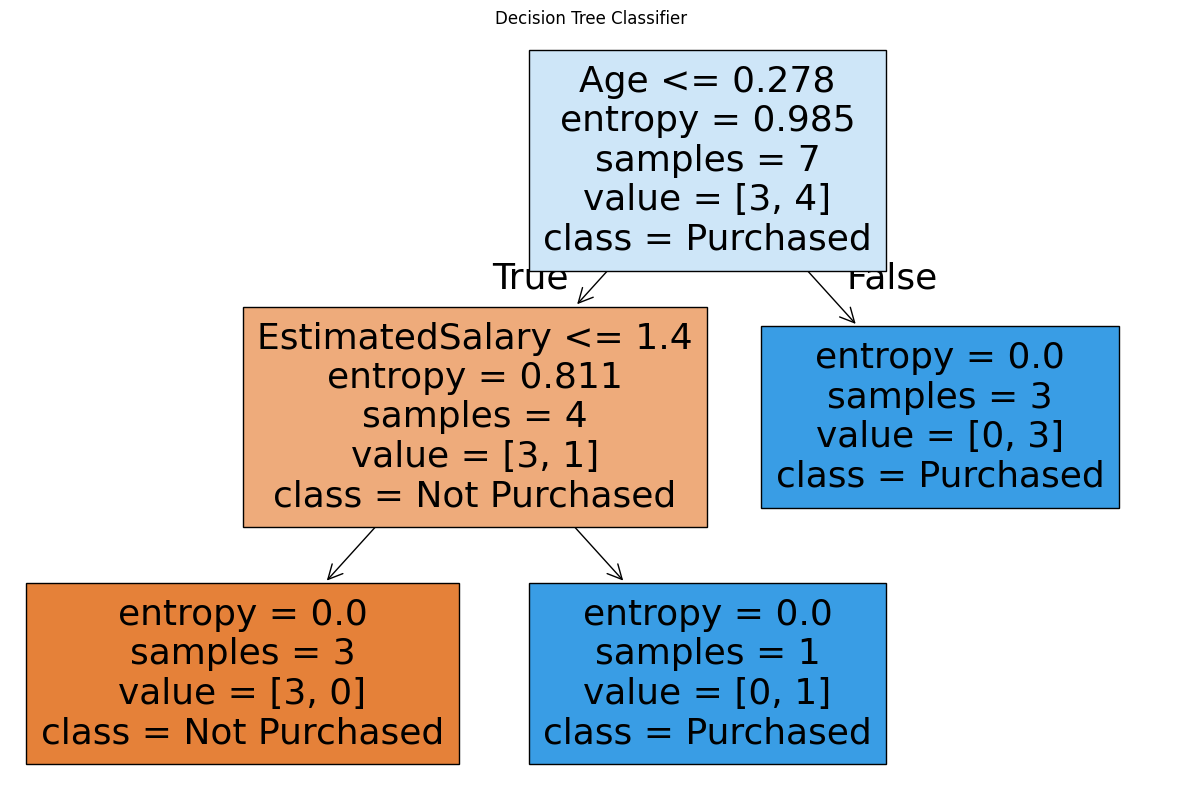

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn import tree


dataset = pd.read_csv(r"C:\Users\akash\OneDrive\Documents\socialnetads.csv")
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

classifier = DecisionTreeClassifier(
    criterion="entropy",
    random_state=0
)

classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print(cm)

print("Accuracy =", accuracy_score(y_test, y_pred))

print(classifier.predict(sc.transform([[30, 87000]])))

plt.figure(figsize=(15,10))
tree.plot_tree(
    classifier,
    filled=True,
    feature_names=["Age", "EstimatedSalary"],
    class_names=["Not Purchased", "Purchased"]
)

plt.title("Decision Tree Classifier")
plt.show()